
# Weighted integral modes for sliding-window point-cloud similarity

This notebook is a weighted version of the drifting Gaussian-mixture tutorial.  It uses the same simulation: one 2D sample per time beat from a slowly drifting Gaussian mixture, with some mixture coefficients forced to zero and then reactivated after a center jump.

The main difference is the initial `CONFIG["mode"]` switch.  Change it to one of:

```python
"plain"          # original integral of component counts
"exponential"   # downweights large radii, reducing domination by long MST edges
"size_weighted" # integrates sum |component|**alpha
"min_size"      # counts only components of at least min_size points
"effective"     # integrates exp(entropy(component size distribution))
```

The notebook computes the selected mode and, by default, computes all modes from the same MSTs so you can compare them without rebuilding linkage trees repeatedly.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Keep pointcloud_similarity.py in the same folder as this notebook.
module_dir = Path.cwd()
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import pointcloud_similarity as pcs
print("Loaded pointcloud_similarity from:", pcs.__file__)
print("pointcloud_similarity version:", getattr(pcs, "__version__", "unknown"))

required = ['pointcloud_similarity_from_common_indices', 'similarity_integrals_from_msts']
missing = [name for name in required if not hasattr(pcs, name)]
if missing:
    raise ImportError(
        "The pointcloud_similarity.py that Python imported is missing "
        f"{missing}. Replace exactly this file: {pcs.__file__!r}. "
        "Do not leave the download named pointcloud_similarity(1).py; rename it to pointcloud_similarity.py, "
        "then restart the notebook kernel."
    )

pointcloud_similarity_from_common_indices = pcs.pointcloud_similarity_from_common_indices
similarity_integrals_from_msts = pcs.similarity_integrals_from_msts


Loaded pointcloud_similarity from: /home/asmi28/python_code/miniSAGA/pointcloud_similarity.py
pointcloud_similarity version: 0.5.1


In [2]:

CONFIG = {
    # Change this one line to switch the scoring mode used in the main plots.
    "mode": "exponential",

    # If True, compute all modes below from the same MSTs.  This is much cheaper
    # than rebuilding the linkage tree once per mode.
    "compute_all_modes": True,

    "seed": 16,
    "T": 500,
    "K": 10,
    "window": 75,

    # Smooth drift parameters.
    "center_scale": 6.0,
    "drift_scale": 0.025,
    "mean_reversion": 0.008,
    "sigma_base": 0.25,
    "sigma_amplitude": 0.40,
    "weight_temperature": 0.80,

    # Teleport parameters applied at component reactivation times.
    "teleport_min_radius": 10.0,
    "teleport_max_radius": 15.0,
    "reactivation_boost": 5.5,
    "boost_duration": 20,

    # Intervals are [start, end). The corresponding mixture coefficient is
    # exactly zero throughout the interval, then the component reappears.
    "zero_intervals": {
        1: [(75, 125), (340, 385)],
        4: [(155, 215)],
        7: [(255, 315)],
        8: [(395, 450)],
    },

    # Mode library.  These dictionaries are passed directly as measure=...
    # to pointcloud_similarity_from_common_indices / similarity_integrals_from_msts.
    "mode_settings": {
        "plain": {"kind": "plain"},
        "exponential": {
            "kind": "exponential",
            "scale": "median_mst_union",
            "half_life": True,
        },
        "size_weighted": {
            "kind": "size_weighted",
            "alpha": 0.5,
        },
        "min_size": {
            "kind": "min_size",
            "min_size": 8,
        },
        "effective": {
            "kind": "effective",
        },
    },
}

MODE = CONFIG["mode"]
MEASURES = CONFIG["mode_settings"]
if MODE not in MEASURES:
    raise ValueError(f"Unknown mode {MODE!r}; choose one of {list(MEASURES)}")

print("Selected mode:", MODE)
print("Selected measure:", MEASURES[MODE])


Selected mode: exponential
Selected measure: {'kind': 'exponential', 'scale': 'median_mst_union', 'half_life': True}


In [3]:

def random_center(rng, r_min, r_max):
    theta = rng.uniform(0, 2 * np.pi)
    radius = rng.uniform(r_min, r_max)
    return np.array([radius * np.cos(theta), radius * np.sin(theta)])


def softmax_masked(logits, active, temperature):
    z = logits / temperature
    z = z.copy()
    z[~active] = -np.inf
    if not np.any(active):
        raise ValueError("At least one component must be active at every time.")
    m = np.max(z[active])
    e = np.zeros_like(z)
    e[active] = np.exp(z[active] - m)
    return e / e.sum()


def simulate_drifting_mixture(config):
    rng = np.random.default_rng(config["seed"])
    T = config["T"]
    K = config["K"]

    active = np.ones((T, K), dtype=bool)
    reactivations = []
    for k, intervals in config["zero_intervals"].items():
        for start, end in intervals:
            active[start:end, k] = False
            if end < T:
                reactivations.append((end, k))

    reactivation_by_time = {}
    for t, k in reactivations:
        reactivation_by_time.setdefault(t, []).append(k)

    home = np.vstack([
        random_center(rng, 3.5, config["center_scale"])
        for _ in range(K)
    ])
    current_centers = home.copy()
    velocities = rng.normal(scale=config["drift_scale"], size=(K, 2))

    centers = np.empty((T, K, 2))
    sigmas = np.empty((T, K))
    weights = np.empty((T, K))

    phase = rng.uniform(0, 2 * np.pi, K)
    phase2 = rng.uniform(0, 2 * np.pi, K)
    freq = rng.uniform(0.010, 0.030, K)
    freq2 = rng.uniform(0.004, 0.012, K)

    for t in range(T):
        if t > 0:
            velocities = 0.96 * velocities + rng.normal(
                scale=config["drift_scale"] * 0.25,
                size=(K, 2),
            )
            current_centers = (
                current_centers
                + velocities
                + config["mean_reversion"] * (home - current_centers)
            )

        # Teleport a component exactly when it leaves a zero-weight interval.
        for k in reactivation_by_time.get(t, []):
            current_centers[k] = random_center(
                rng,
                config["teleport_min_radius"],
                config["teleport_max_radius"],
            )
            velocities[k] = rng.normal(scale=config["drift_scale"], size=2)

        centers[t] = current_centers

        logits = (
            1.1 * np.sin(freq * t + phase)
            + 0.7 * np.cos(freq2 * t + phase2)
        )
        for t0, k in reactivations:
            if t0 <= t < min(T, t0 + config["boost_duration"]):
                logits[k] += config["reactivation_boost"]

        weights[t] = softmax_masked(logits, active[t], config["weight_temperature"])
        sigmas[t] = np.clip(
            config["sigma_base"] * (1 + config["sigma_amplitude"] * np.sin(0.025 * t + phase2)),
            0.08,
            None,
        )

    components = np.empty(T, dtype=int)
    points = np.empty((T, 2))
    for t in range(T):
        components[t] = rng.choice(K, p=weights[t])
        points[t] = rng.normal(centers[t, components[t]], sigmas[t, components[t]])

    return points, components, weights, centers, sigmas, active, reactivations


In [4]:

points, components, weights, centers, sigmas, active, reactivations = simulate_drifting_mixture(CONFIG)

print(f"points shape: {points.shape}")
print("reactivations (time, component):", reactivations)


points shape: (500, 2)
reactivations (time, component): [(125, 1), (385, 1), (215, 4), (315, 7), (450, 8)]


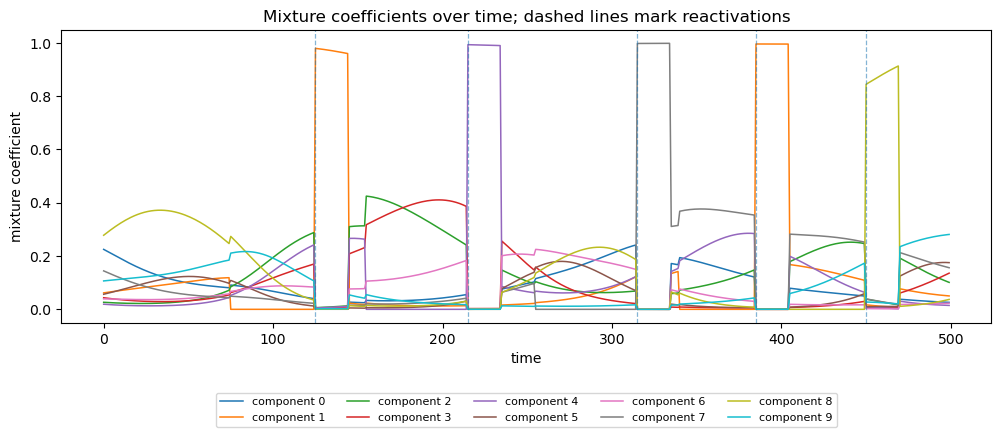

In [5]:

fig, ax = plt.subplots(figsize=(12, 3.8))
for k in range(CONFIG["K"]):
    ax.plot(weights[:, k], linewidth=1.1, label=f"component {k}")
for t, k in reactivations:
    ax.axvline(t, linestyle="--", linewidth=0.9, alpha=0.55)
ax.set_title("Mixture coefficients over time; dashed lines mark reactivations")
ax.set_xlabel("time")
ax.set_ylabel("mixture coefficient")
ax.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.22))
plt.show()


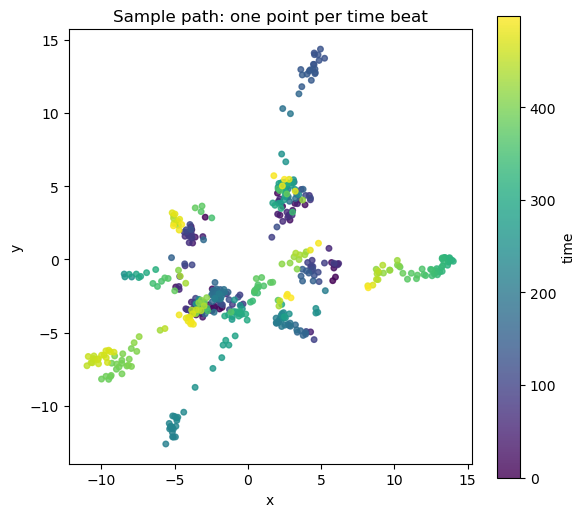

In [6]:

fig, ax = plt.subplots(figsize=(6.5, 6.0))
scatter = ax.scatter(points[:, 0], points[:, 1], c=np.arange(CONFIG["T"]), s=16, alpha=0.8)
ax.set_title("Sample path: one point per time beat")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
plt.colorbar(scatter, ax=ax, label="time")
plt.show()



## Compute sliding-window scores

For every consecutive pair of windows,

```python
X_t = points[t : t + window]
Y_t = points[t + 1 : t + window + 1]
```

we build the one-swap MSTs once.  If `compute_all_modes=True`, all weighted integrals are then evaluated from those same MSTs.


In [7]:

def _score_from_integrals(I_X, I_Y, I_union):
    return np.nan if I_union == 0 else (I_X + I_Y - I_union) / I_union


def compute_sliding_scores(points, components, weights, config, reactivations):
    T = config["T"]
    W = config["window"]
    selected_mode = config["mode"]
    mode_library = config["mode_settings"]
    active_measures = mode_library if config["compute_all_modes"] else {selected_mode: mode_library[selected_mode]}

    records = []
    measure_infos = {}

    for start in range(T - W):
        # X = [start, ..., start+W-1]
        # Y = [start+1, ..., start+W]
        common_indices = np.arange(start + 1, start + W)
        x_index = start
        y_index = start + W

        # Build the linkage/MST objects once.  The measure below is plain only
        # because we are going to evaluate the selected/all modes from the MSTs.
        base = pointcloud_similarity_from_common_indices(
            points,
            common_indices,
            x_index=x_index,
            y_index=y_index,
            mst_method="delaunay",
            measure="plain",
        )

        union_indices = np.r_[common_indices, np.asarray([x_index, y_index], dtype=np.int64)]
        union_points = points[union_indices]

        record = {
            "window_start": start,
            "t_added": y_index,
            "R": base.R,
            "conn_X": base.mst_X.max_edge,
            "conn_Y": base.mst_Y.max_edge,
            "conn_union": base.mst_union.max_edge,
            "removed_index": x_index,
            "added_index": y_index,
            "removed_component": int(components[x_index]),
            "added_component": int(components[y_index]),
            "added_component_weight": weights[y_index, int(components[y_index])],
        }

        added_component = record["added_component"]
        record["reactivation_sample"] = any(
            (added_component == k) and (t0 <= y_index < t0 + config["boost_duration"])
            for t0, k in reactivations
        )
        record["near_reactivation"] = any(
            t0 <= y_index < t0 + config["boost_duration"]
            for t0, _ in reactivations
        )

        for mode_name, measure in active_measures.items():
            I_X, I_Y, I_union, info = similarity_integrals_from_msts(
                base.mst_X,
                base.mst_Y,
                base.mst_union,
                base.R,
                measure=measure,
                union_points=union_points,
            )
            measure_infos.setdefault(mode_name, info)
            record[f"I_X_{mode_name}"] = I_X
            record[f"I_Y_{mode_name}"] = I_Y
            record[f"I_union_{mode_name}"] = I_union
            record[f"s_{mode_name}"] = _score_from_integrals(I_X, I_Y, I_union)

        record["s"] = record[f"s_{selected_mode}"]
        record["I_union"] = record[f"I_union_{selected_mode}"]
        records.append(record)

    return pd.DataFrame(records), measure_infos


scores, measure_infos = compute_sliding_scores(points, components, weights, CONFIG, reactivations)
print("Measure info used in the first window for each computed mode:")
for name, info in measure_infos.items():
    print(f"  {name}: {info}")

summary_cols = ["s", "I_union", "R", "conn_X", "conn_Y", "conn_union"]
scores.describe()[summary_cols]


Measure info used in the first window for each computed mode:
  plain: {'kind': 'plain'}
  exponential: {'kind': 'exponential', 'kernel': 'exponential', 'lambda': 2.928313655785892, 'scale': 0.23670523790728304, 'scale_source': 'median_mst_union', 'half_life': True}
  size_weighted: {'kind': 'size_weighted', 'alpha': 0.5}
  min_size: {'kind': 'min_size', 'min_size': 8}
  effective: {'kind': 'effective'}


,s,I_union,R,conn_X,conn_Y,conn_union
count,425.000000,425.000000,425.000000,425.000000,425.000000,425.000000
mean,0.976832,16.600983,6.785367,6.749680,6.750049,6.740840
std,0.009240,3.254648,1.820702,1.807552,1.807199,1.798095
min,0.953743,11.981376,4.499066,4.499066,4.499066,4.499066
25%,0.970457,14.017077,4.965900,4.965900,4.965900,4.965900
50%,0.977605,15.310520,6.704052,6.704052,6.704052,6.704052
75%,0.983794,18.794869,8.119510,8.058880,8.058880,8.058880
max,0.996623,24.942000,11.009233,11.009233,11.009233,11.009233


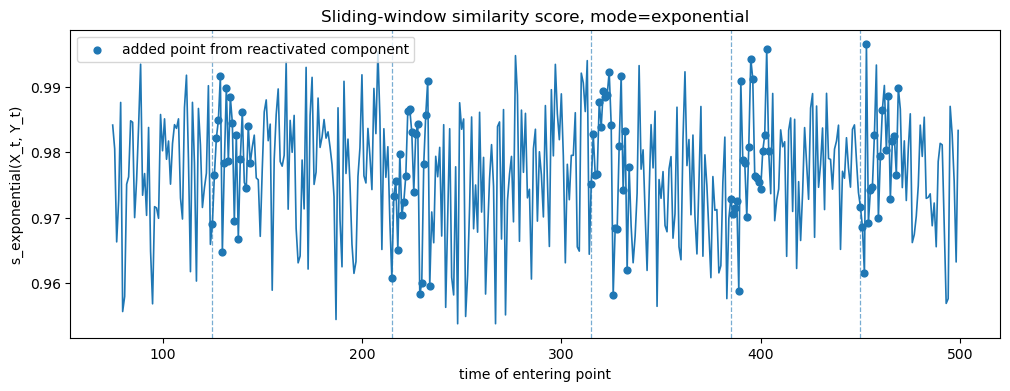

In [8]:

fig, ax = plt.subplots(figsize=(12, 4.0))
ax.plot(scores["t_added"], scores["s"], linewidth=1.2)
for t, k in reactivations:
    ax.axvline(t, linestyle="--", linewidth=0.9, alpha=0.6)
ax.scatter(
    scores.loc[scores["reactivation_sample"], "t_added"],
    scores.loc[scores["reactivation_sample"], "s"],
    s=24,
    label="added point from reactivated component",
)
ax.set_title(f"Sliding-window similarity score, mode={MODE}")
ax.set_xlabel("time of entering point")
ax.set_ylabel(f"s_{MODE}(X_t, Y_t)")
ax.legend(loc="best")
plt.show()


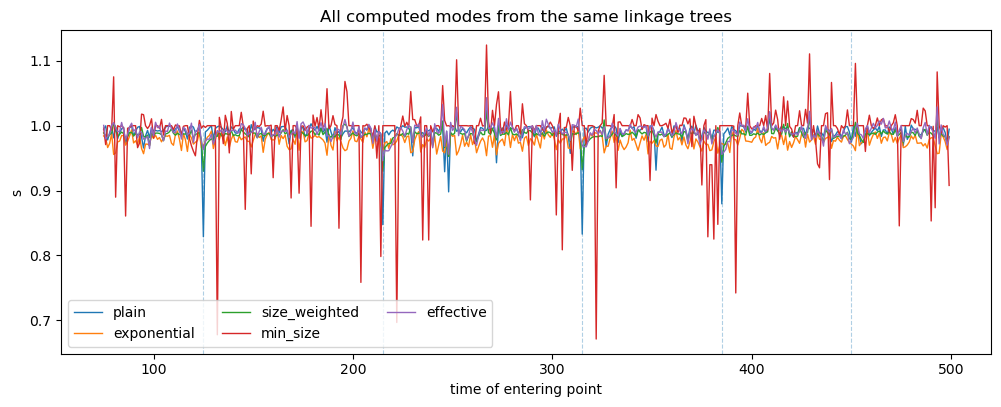

In [9]:

score_columns = [f"s_{name}" for name in MEASURES if f"s_{name}" in scores.columns]

if len(score_columns) > 1:
    fig, ax = plt.subplots(figsize=(12, 4.2))
    for col in score_columns:
        ax.plot(scores["t_added"], scores[col], linewidth=1.0, label=col[2:])
    for t, k in reactivations:
        ax.axvline(t, linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_title("All computed modes from the same linkage trees")
    ax.set_xlabel("time of entering point")
    ax.set_ylabel("s")
    ax.legend(loc="best", ncol=3)
    plt.show()
else:
    print("Only the selected mode was computed. Set CONFIG['compute_all_modes'] = True to compare modes.")


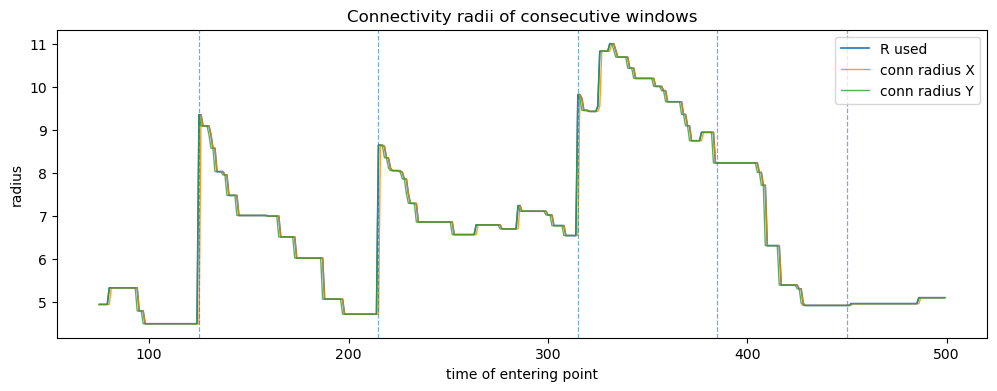

In [10]:

fig, ax = plt.subplots(figsize=(12, 4.0))
ax.plot(scores["t_added"], scores["R"], linewidth=1.2, label="R used")
ax.plot(scores["t_added"], scores["conn_X"], linewidth=1.0, alpha=0.8, label="conn radius X")
ax.plot(scores["t_added"], scores["conn_Y"], linewidth=1.0, alpha=0.8, label="conn radius Y")
for t, k in reactivations:
    ax.axvline(t, linestyle="--", linewidth=0.9, alpha=0.6)
ax.set_title("Connectivity radii of consecutive windows")
ax.set_xlabel("time of entering point")
ax.set_ylabel("radius")
ax.legend(loc="best")
plt.show()


In [11]:

# The lowest selected-mode scores are the most visually obvious changes under this simulation.
cols = [
    "t_added", "s", "I_union", "R", "conn_X", "conn_Y",
    "removed_component", "added_component",
    "added_component_weight", "reactivation_sample", "near_reactivation",
]
scores.nsmallest(12, "s")[cols]


,t_added,s,I_union,R,conn_X,conn_Y,removed_component,added_component,added_component_weight,reactivation_sample,near_reactivation
173,248,0.953743,12.638370,6.863535,6.863535,6.863535,6,0,0.094502,False,False
192,267,0.953747,13.240525,6.796693,6.796693,6.796693,8,4,0.062027,False,False
112,187,0.954394,18.323246,6.024545,6.024545,5.070929,6,1,0.013078,False,False
177,252,0.954853,12.802444,6.863535,6.863535,6.571626,8,4,0.064055,False,False
197,272,0.955098,13.405846,6.796693,6.796693,6.796693,1,8,0.196762,False,False
5,80,0.955607,14.308636,5.333112,4.947699,5.333112,9,0,0.087540,False,False
167,242,0.956253,12.432655,6.863535,6.863535,6.863535,2,7,0.075676,False,False
273,348,0.956409,13.968395,10.202886,10.202886,10.202886,4,0,0.183230,False,False
20,95,0.956792,14.017077,4.796680,4.796680,4.796680,2,2,0.170001,False,False
418,493,0.956857,17.183832,5.104402,5.104402,5.104402,1,3,0.117571,False,False


In [12]:

if len(score_columns) > 1:
    # Pairwise correlations show which weighted modes are behaving similarly.
    scores[score_columns].corr()


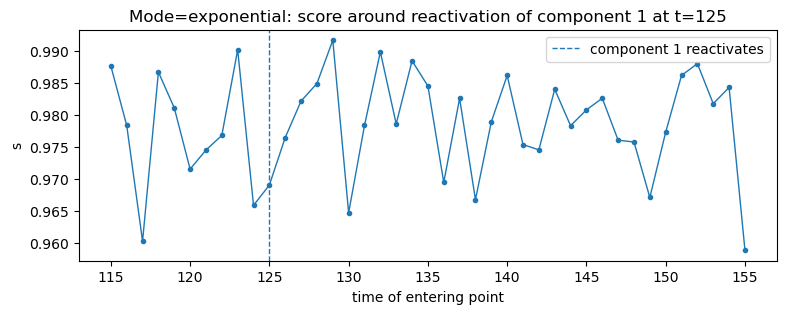

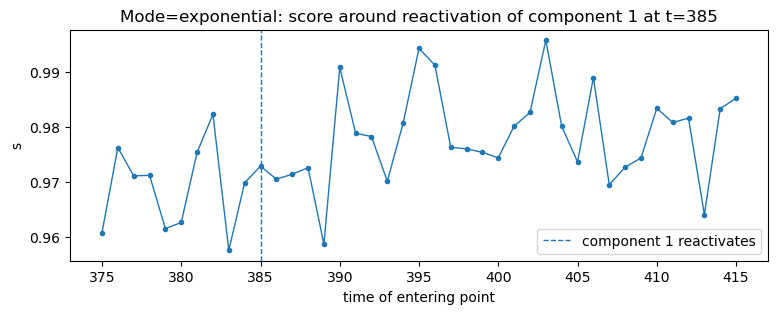

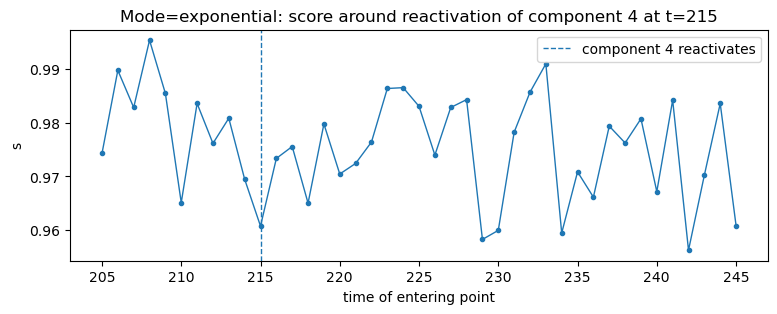

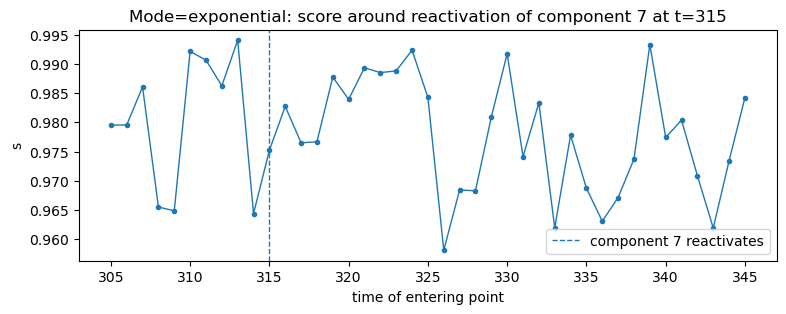

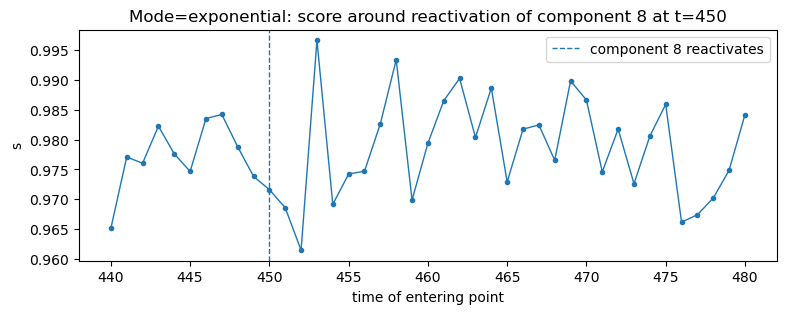

In [13]:

# Zoom around every reactivation. The entering time t_added is the natural x-axis.
for t0, k in reactivations:
    lo = max(scores["t_added"].min(), t0 - 10)
    hi = min(scores["t_added"].max(), t0 + CONFIG["boost_duration"] + 10)
    chunk = scores[(scores["t_added"] >= lo) & (scores["t_added"] <= hi)]

    fig, ax = plt.subplots(figsize=(9, 3.0))
    ax.plot(chunk["t_added"], chunk["s"], marker="o", linewidth=1.0, markersize=3)
    ax.axvline(t0, linestyle="--", linewidth=1.0, label=f"component {k} reactivates")
    ax.set_title(f"Mode={MODE}: score around reactivation of component {k} at t={t0}")
    ax.set_xlabel("time of entering point")
    ax.set_ylabel("s")
    ax.legend(loc="best")
    plt.show()



## Tuning suggestions

- Change `CONFIG["mode"]` first; that is the fastest way to see how the score changes.
- For `"exponential"`, try `"scale": "median_nn_union"`, `"p90_mst_union"`, or a fixed numeric scale.  With `"half_life": True`, the weight is halved at the chosen scale.
- For `"size_weighted"`, try `alpha=0.25`, `0.5`, or `0.75`.  `alpha=0` recovers the original component count.
- For `"min_size"`, set `min_size` relative to the window.  Values around 5–15 are often useful for a 75-point window.
- Increase `teleport_min_radius` / `teleport_max_radius` to make reactivated blobs farther away.
- Increase `reactivation_boost` to make the reactivated component more likely to be sampled immediately.
- Decrease `window` to make each entering point have more influence.
